In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [13]:
data = pd.read_excel("hospitalData.xlsx", 
                     # engine='openpyxl',
                     # password='GEMH'
                    )
data.shape

(441, 30)

In [14]:
# we can drop firstname and lastname columns
data = data.drop(columns=['Program ID','First Name','Last Name'])

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 441 entries, 0 to 440
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   HTN Patient Type             346 non-null    object 
 1   HTN Known Patient Year       193 non-null    float64
 2   Diabetes Patient Type        141 non-null    object 
 3   Diabetes Known Patient Year  82 non-null     float64
 4   Confirmed Diagnosis          441 non-null    object 
 5   Latest Age                   441 non-null    int64  
 6   Latest BMI                   440 non-null    float64
 7   Latest BMI Date              441 non-null    object 
 8   Latest CVD Risk Score        425 non-null    object 
 9   Physical Activity            310 non-null    object 
 10  Alcohol Use                  298 non-null    object 
 11  Alcohol Status               5 non-null      float64
 12  Tobacco Use                  298 non-null    object 
 13  Tobacco Status      

In [15]:
data.head()

,HTN Patient Type,HTN Known Patient Year,Diabetes Patient Type,Diabetes Known Patient Year,Confirmed Diagnosis,Latest Age,Latest BMI,Latest BMI Date,Latest CVD Risk Score,Physical Activity,...,Latest Systolic,Latest Diastolic,Date Of Last BG Assessment,Latest Glucose Type,Latest Glucose Value,Date Of Last Medical Review,Medication Prescribed,Comorbidity,Complication Status,Landmark
0,Known Patient,2000.0,NaN,NaN,Hypertension,87,18.26,18/07/2022,Low risk - 9%,NaN,...,114,73,18/07/2022,fbs,5.6,NaN,"Nifedipine,Amlodipine,Losartan",NaN,NaN,anwomaso new site
1,Known Patient,2019.0,Known Patient,2019.0,"Hypertension,Diabetes Mellitus Type 1",61,40.51,14/07/2024,Low risk - 9%,NaN,...,156,101,23/01/2024,fbs,7.2,16/07/2024,"Losartan,Bendrofluazide,Gliclazide,Pioglitazon...",NaN,NaN,anwomaso
2,Known Patient,2016.0,NaN,NaN,Hypertension,79,22.22,21/02/2022,Medium risk - 13%,NaN,...,124,68,NaN,NaN,NaN,NaN,"Bendrofluazide,Amlodipine",NaN,NaN,kenyase
3,Known Patient,2021.0,NaN,NaN,Hypertension,86,38.25,26/09/2022,Medium risk - 16%,NaN,...,150,71,NaN,NaN,NaN,27/09/2022,"Losartan,paracetamol ,Nifedipine",NaN,NaN,anwomaso
4,Known Patient,2019.0,Known Patient,2019.0,"Hypertension,Diabetes Mellitus Type 1",51,51.13,22/02/2022,Low risk - 2%,NaN,...,107,70,22/02/2022,fbs,5.1,NaN,"Metformin,Amlodipine",NaN,NaN,oforikrom


In [16]:
data.describe()

,HTN Known Patient Year,Diabetes Known Patient Year,Latest Age,Latest BMI,Alcohol Status,Tobacco Status,Latest Systolic,Latest Diastolic,Latest Glucose Value
count,193.000000,82.000000,441.000000,440.000000,5.00000,1.0,441.000000,441.000000,326.000000
mean,2014.590674,2015.817073,65.585034,29.133795,1613.60000,1980.0,136.750567,81.061224,8.101227
std,8.819564,6.811624,12.653158,8.404476,898.12655,NaN,21.289699,12.223612,3.647414
min,1973.000000,1990.000000,35.000000,15.430000,7.00000,1980.0,100.000000,54.000000,3.400000
25%,2012.000000,2013.250000,57.000000,23.427500,2009.00000,1980.0,121.000000,73.000000,5.400000
50%,2018.000000,2018.500000,64.000000,27.500000,2014.00000,1980.0,132.000000,80.000000,6.800000
75%,2020.000000,2020.000000,73.000000,32.690000,2018.00000,1980.0,150.000000,87.000000,9.300000
max,2024.000000,2023.000000,96.000000,71.660000,2020.00000,1980.0,216.000000,127.000000,20.000000


In [17]:
data.columns

Index(['HTN Patient Type', 'HTN Known Patient Year', 'Diabetes Patient Type',
       'Diabetes Known Patient Year', 'Confirmed Diagnosis', 'Latest Age',
       'Latest BMI', 'Latest BMI Date', 'Latest CVD Risk Score',
       'Physical Activity', 'Alcohol Use', 'Alcohol Status', 'Tobacco Use',
       'Tobacco Status', 'Gender', 'Date Of Enrollment',
       'Date Of Last BP Assessment', 'Latest Systolic', 'Latest Diastolic',
       'Date Of Last BG Assessment', 'Latest Glucose Type',
       'Latest Glucose Value', 'Date Of Last Medical Review',
       'Medication Prescribed', 'Comorbidity', 'Complication Status',
       'Landmark'],
      dtype='object')

In [18]:
identifiers = ['Program ID']

demographic_features = [ 'Latest Age','Gender']

clinical_cond_info =['HTN Patient Type',
                     'HTN Known Patient Year',
                     'Diabetes Patient Type',
                     'Diabetes Known Patient Year', 
                     'Confirmed Diagnosis',
                     'Comorbidity', 
                     'Complication Status']

risk_factor = ['Latest BMI',
               'Latest BMI Date',
               'Latest CVD Risk Score',
               'Physical Activity', 
               'Alcohol Use', 
               'Alcohol Status', 
               'Tobacco Use',
               'Tobacco Status']

clinicial_measurements = ['Date Of Last BP Assessment', 
                          'Latest Systolic',
                          'Latest Diastolic',
                           'Date Of Last BG Assessment',
                          'Latest Glucose Type',
                           'Latest Glucose Value']

treatment_info =['Medication Prescribed',
                 'Date Of Last Medical Review']

geo_factor = ['Landmark']


In [20]:
key_risk_indicators = {'obesity_indicator':['Latest BMI', 
                                            'Latest BMI Date'],
                       
                       'diabetic_indicators': ['Latest Glucose Value']
                       
                       'cardiovascular_indicator':['Latest CVD Risk Score',
                                                   'Latest Systolic',
                                                   'Latest Diastolic'],
                       
                       'lifestyle_predictors':['Physical Activity', 
                                               'Alcohol Use', 
                                               'Alcohol Status', 
                                               'Tobacco Use',
                                               'Tobacco Status']
                                          }


# going forawrd you would have to declare ranges for each risk level eg. 1-10 :  1-3 low; 4-7 normal; 7-10 high
# 

In [23]:
# For Digital Twin simulation 
# this is the data you will be manipulating to check patient outcomes
simulation_target_data = {
    'diabetes': ['Latest Glucose Type','Latest Glucose Value'],
    'hypertension': ['Latest Systolic', 'Latest Diastolic'],
    'comorbidity': ['Comorbidity']
}

In [ ]:
# categorical features
cat_names=['HTN Patient Type','Diabetes Patient Type','Confirmed Diagnosis',
                    'Physical Activity','Alcohol Use','Alcohol Status','Tobacco Use',
                    'Tobacco Status','Gender'
                    ]

# continuous features
cont_names= ['']





In [26]:
age_demographics = {
                     'kid': range(0,13),
                      'teenager': range(13,20),  
                        'young_adult': range(20,36),
                        'adult':range(36,51),
                        'senior_adult': range(51,60),
                        'pensioner': range(60,200)
    
                        }

def get_age_group(age):
    for group, age_range in age_demographics.items():
        if age in age_range:
            return group

data['Age_Group'] = data['Latest Age'].apply(get_age_group)

data.head()
    

,HTN Patient Type,HTN Known Patient Year,Diabetes Patient Type,Diabetes Known Patient Year,Confirmed Diagnosis,Latest Age,Latest BMI,Latest BMI Date,Latest CVD Risk Score,Physical Activity,...,Latest Diastolic,Date Of Last BG Assessment,Latest Glucose Type,Latest Glucose Value,Date Of Last Medical Review,Medication Prescribed,Comorbidity,Complication Status,Landmark,Age_Group
0,Known Patient,2000.0,NaN,NaN,Hypertension,87,18.26,18/07/2022,Low risk - 9%,NaN,...,73,18/07/2022,fbs,5.6,NaN,"Nifedipine,Amlodipine,Losartan",NaN,NaN,anwomaso new site,pensioner
1,Known Patient,2019.0,Known Patient,2019.0,"Hypertension,Diabetes Mellitus Type 1",61,40.51,14/07/2024,Low risk - 9%,NaN,...,101,23/01/2024,fbs,7.2,16/07/2024,"Losartan,Bendrofluazide,Gliclazide,Pioglitazon...",NaN,NaN,anwomaso,pensioner
2,Known Patient,2016.0,NaN,NaN,Hypertension,79,22.22,21/02/2022,Medium risk - 13%,NaN,...,68,NaN,NaN,NaN,NaN,"Bendrofluazide,Amlodipine",NaN,NaN,kenyase,pensioner
3,Known Patient,2021.0,NaN,NaN,Hypertension,86,38.25,26/09/2022,Medium risk - 16%,NaN,...,71,NaN,NaN,NaN,27/09/2022,"Losartan,paracetamol ,Nifedipine",NaN,NaN,anwomaso,pensioner
4,Known Patient,2019.0,Known Patient,2019.0,"Hypertension,Diabetes Mellitus Type 1",51,51.13,22/02/2022,Low risk - 2%,NaN,...,70,22/02/2022,fbs,5.1,NaN,"Metformin,Amlodipine",NaN,NaN,oforikrom,senior_adult


In [31]:
data['Age_Group'].value_counts()

Age_Group
pensioner       300
senior_adult     91
adult            48
young_adult       2
Name: count, dtype: int64

<Axes: ylabel='Age_Group'>

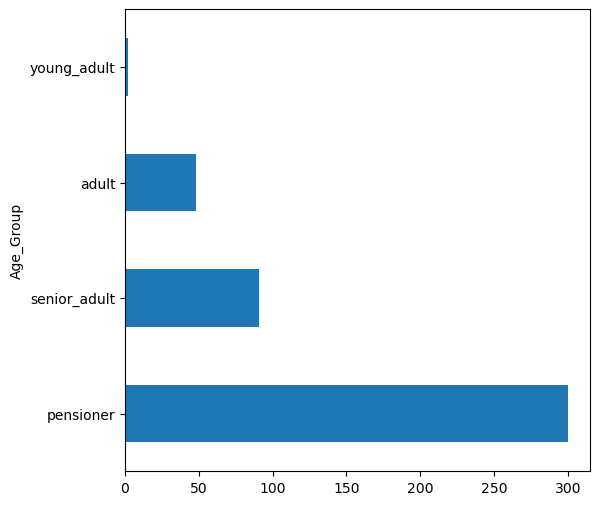

In [35]:
data['Age_Group'].value_counts().plot(kind='barh', figsize=(6,6))